<IPython.core.display.Latex object>

Good! File exists!


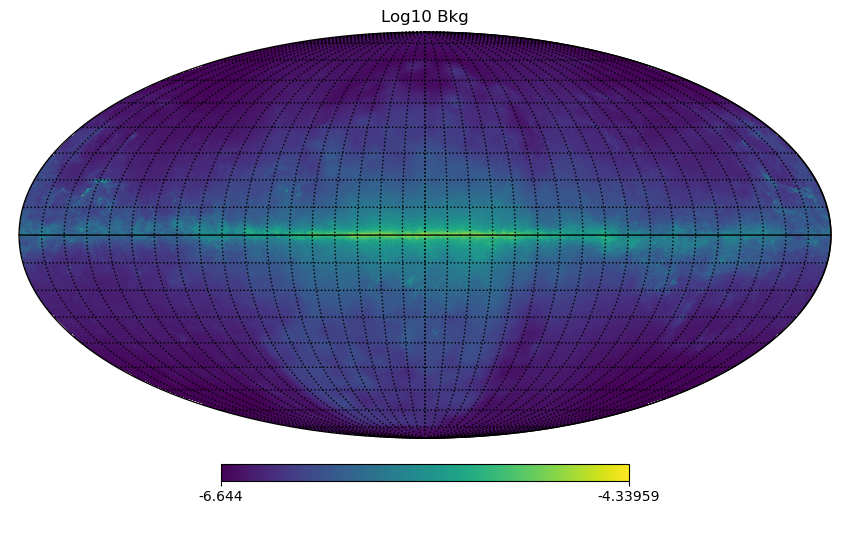

In [1]:
import sys
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
import tqdm
from astropy.io import fits
from firesong.Firesong import firesong_simulation
from multiprocessing import Pool
%matplotlib ipympl
from IPython.display import Latex,display
sys.path.append('../LHAASO_PSF/PSFConv/') 
import Plot
import PSF
import os
import time

#------------------------参数设置----------------------------------

xsize = 640 #卷积前的图像尺寸，每像素对应尺度为 2*radius/xsize, 这个值应当设置得较小。
radius = 6.4 #图像半径， 可以修改至6.4,这样最后出来的图宽度为128
pixelwidth = radius*2/xsize
display(Latex('Pixel Width: $%.2f ^ \\circ/\\mathrm{pixel}$'%pixelwidth))
nfigure = 16 #生成多少张训练图像,要求是28的倍数（有28个能量段）
ra_center = np.mod(np.linspace(0,360*28,nfigure),360) #每张图像的中心坐标
dec_center = np.mod(np.linspace(0,180*28,nfigure),180)-90
energy_idx = np.floor(np.linspace(0,360*28,nfigure)/360)#每张图对应的能量索引
NPROC = 16 # 线程数
RANDOMPSF = True #是否将psf进行随机微调 
POINTSRC = 0 # 添加点源的最大数量每图

psfradius = 1. #尽量不要修改，这里为了节约计算量，忽略了大于该半径的psf作用效果。（PSF卷积核半径）

binsize = 0.1  #单位是度，必须大于卷积前像素的尺度

NSIDE = 2048  #初始分辨率

#-------------------------程序主体----------------------------------

#检查背景文件是否存在
if os.path.exists('./gll_iem_v07.fits'):
    print('Good! File exists!')
else:
    print('File not found, start downloading.')
    os.system('wget https://fermi.gsfc.nasa.gov/ssc/data/analysis/software/aux/4fgl/gll_iem_v07.fits')
#galabkg = np.load('Fermi-LAT_pi0_map.npy')
#galabkg = hp.ud_grade(galabkg,NSIDE)
hdulist = fits.open('gll_iem_v07.fits')


data = hdulist[0].data[0,:,:]
galabkg = Plot.img2healpix(512,1024,data)


hp.mollview(np.log10(galabkg),rot = (180,0),title='Log10 Bkg')
hp.graticule(dpar = 10,dmer=10)

In [3]:
#！！！！！！！！！！！！！！！！！！！！！请不要随意修改如下部分！！！！！！！！！！！！！！！！！！！！！

ROI = []
ROI_BLUR = []





def process(idx):
    np.random.seed(int((time.time()-int(time.time()))*1e6))

    # 返回拟合的lhaaso psf以及目标的高斯psf
    #randompsf参数可以调节是否将psf进行随机微调
    psfconv,targetconv= PSF.fitpsf(0,plot=False,randomPSF = RANDOMPSF)

    if POINTSRC != 0:
        pointsrc = np.random.randint(POINTSRC)
    else:
        pointsrc = 0

    
    ra_c,dec_c,i = idx
    #------真实坐标不重要---------
    npixedge = int(psfradius/pixelwidth)+1
    x = np.linspace(-radius+pixelwidth,radius,xsize)
    y = np.linspace(-radius+pixelwidth,radius,xsize)


    #含有边界，边界上psf无法很好卷积，会出现异常值。这里先包括额外的边界，然后卷积，然后再删掉边界
    x_edge = np.linspace(-radius-psfradius+pixelwidth,radius+psfradius,xsize+2*npixedge)
    y_edge = np.linspace(-radius-psfradius+pixelwidth,radius+psfradius,xsize+2*npixedge)

    #----------------按照中心坐标和半径选取天区-----------------------

    
    roi = Plot.selectreg_interp(galabkg,ra_c,dec_c,radius+psfradius,NSIDE,xsize=xsize+2*npixedge,plot = False)

    if pointsrc != 0 :
        for niter in range(pointsrc):
            ix_src = int(np.random.randint(int(xsize*0.8)) + npixedge)
            iy_src = int(np.random.randint(int(xsize*0.8)) + npixedge)
            roi[ix_src+int(xsize*0.1),iy_src+int(xsize*0.1)] += roi.max()*np.random.uniform(10,30)

    
    #print(roi.shape)
    #------------对图像逐一卷积，如果卷积前分辨率很高，耗时会很长。--------------------
    #使用了scipy.signal.convolve2d来卷积
    roi_blur_tmp,psf_tuple = psfconv(roi,x_edge,y_edge,psfradius=psfradius,returnPSF = True)
    roi_blur = roi_blur_tmp[npixedge:-npixedge,npixedge:-npixedge]

    #这里原始清晰图像也需要用一个psf卷积以下作为重建的目标。
    #用一个高斯psf来卷积，target_sig = 0.1是该高斯的sigma参数。
    roi = targetconv(roi,x_edge,y_edge
                     ,target_sig = 0.1,psfradius=psfradius
                    )[npixedge:-npixedge,npixedge:-npixedge]
    #print(roi.shape)
    #print(npixedge)

    #-----------------重新分bin---------------------
    roi_rebin,xx,yy  = PSF.bindata(roi,x,y,binsize)
    blur_rebin,xx,yy = PSF.bindata(roi_blur,x,y,binsize)

    #if np.mod(i,10) == 0:
    #    print('finish fig %d' %i)
    return (roi_rebin,blur_rebin,psf_tuple)
    #ROI.append(roi_rebin)
    #ROI_BLUR.append(blur_rebin)


res = []

print('begin MP: simulating, total energy:28')
t_begin = time.time()

for eidx in range(int(energy_idx.max())):
    
    
    
    
    
    idx = []
    for i in range(nfigure):
        if energy_idx[i] == eidx:
            idx.append((ra_center[i],dec_center[i],i))
    if len(idx) == 0:
        continue

    data = hdulist[0].data[eidx,:,:]
    galabkg = Plot.img2healpix(512,1024,data)
        
    with Pool(NPROC) as pool:
        restmp=pool.map(process,idx)
    res.extend(restmp)
    print('finish energy %d, time used %.2f'%(eidx,time.time()-t_begin))
        
res = np.array(res,dtype= object)

begin MP: simulating, total energy:28
finish energy 0, time used 27.17
finish energy 1, time used 48.21
finish energy 3, time used 69.71
finish energy 5, time used 90.68
finish energy 7, time used 111.63
finish energy 9, time used 132.76
finish energy 11, time used 153.74
finish energy 13, time used 174.91
finish energy 14, time used 195.77
finish energy 16, time used 217.04
finish energy 18, time used 238.90
finish energy 20, time used 260.60
finish energy 22, time used 281.82
finish energy 24, time used 303.43
finish energy 26, time used 324.45


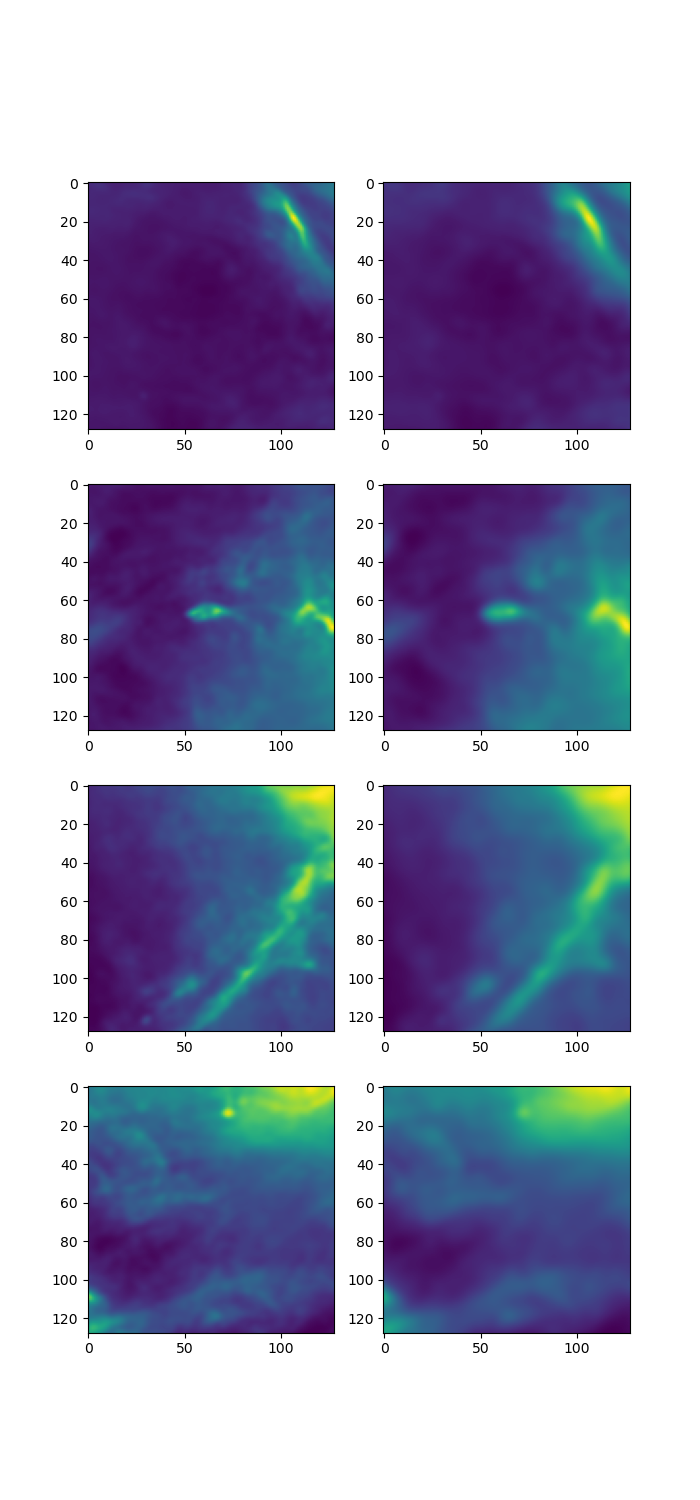

In [4]:
a = 0
fig,ax = plt.subplots(4,2,figsize = (7,15))
for a in range(4):
    ax[a][0].imshow(res[a][0])
    ax[a][1].imshow(res[a][1])


In [ ]:
time.time()

In [ ]:
np.save('../SimulatedData/rand_PSF.npy',res)
#res[i,0] -----original
#res[i,1] -----blur
#res[i,2] -----tuple (angle,psf(angle))
#np.save('../SimulatedData/blurred.npy',res[:,1,:,:])

In [ ]:
'''

def processtmp():
    #ra_c,dec_c,i = idx
    #------真实坐标不重要---------
    npixedge = int(psfradius/pixelwidth)+1
    x = np.linspace(-radius+pixelwidth,radius,xsize)
    y = np.linspace(-radius+pixelwidth,radius,xsize)


    #含有边界，边界上psf无法很好卷积，会出现异常值。这里先包括额外的边界，然后卷积，然后再删掉边界
    x_edge = np.linspace(-radius-psfradius+pixelwidth,radius+psfradius,xsize+2*npixedge)
    y_edge = np.linspace(-radius-psfradius+pixelwidth,radius+psfradius,xsize+2*npixedge)

    #----------------按照中心坐标和半径选取天区-----------------------
    xsize2 = xsize+2*npixedge
    arr = np.zeros((xsize2,xsize2))
    arr[int(xsize2/2),int(xsize2/4)]+= 1
    arr[int(xsize2/2),int(xsize2*3/4)]+= 1
    roi = arr#Plot.selectreg_interp(galabkg,ra_c,dec_c,radius+psfradius,NSIDE,xsize=xsize+2*npixedge,plot = False)
    #print(roi.shape)
    #------------对图像逐一卷积，如果卷积前分辨率很高，耗时会很长。--------------------
    #使用了scipy.signal.convolve2d来卷积
    roi_blur = psfconv(roi,x_edge,y_edge,psfradius=psfradius)[npixedge:-npixedge,npixedge:-npixedge]
    roi = roi[npixedge:-npixedge,npixedge:-npixedge]
    print(roi.shape)
    print(roi.shape)
    #print(npixedge)

    #-----------------重新分bin---------------------
    roi_rebin,xx,yy  = PSF.bindata(roi,x,y,binsize)
    blur_rebin,xx,yy = PSF.bindata(roi_blur,x,y,binsize)
    

    if np.mod(i,10) == 0:
        print('finish fig %d' %i)
    return (roi_rebin,blur_rebin)
    #ROI.append(roi_rebin)
    #ROI_BLUR.append(blur_rebin)

res_tmp = processtmp()
'''
